In [1]:
"""Plot predeclared, training-only causal CSP latency sensitivity.

Run `stroke-rehab latency-audit` from the repository root first. This plot
visualizes a potential feedback confound, not a window-selection objective.
"""
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import numpy as np

source = Path("results/causal_latency_audit.csv")
rows = list(csv.DictReader(source.open(newline="")))
assert len(rows) == 24 and all(int(r["trials"]) == 80 for r in rows)
print("Training-only fixed CSP-1: correct of 80 at each endpoint")
for p in ("P1", "P2", "P3"):
    for session in ("pre", "post"):
        subset = sorted((r for r in rows if r["patient"] == p and r["session"] == session),
                        key=lambda r: float(r["stop_s"]))
        print(f"{p} {session.upper()}: " + ", ".join(
            f"{r['stop_s']}s={r['correct']}/80" for r in subset))


Training-only fixed CSP-1: correct of 80 at each endpoint
P1 PRE: 3.5s=70/80, 4.5s=73/80, 5.5s=75/80, 6.5s=73/80
P1 POST: 3.5s=76/80, 4.5s=77/80, 5.5s=80/80, 6.5s=77/80
P2 PRE: 3.5s=46/80, 4.5s=52/80, 5.5s=60/80, 6.5s=71/80
P2 POST: 3.5s=46/80, 4.5s=58/80, 5.5s=68/80, 6.5s=76/80
P3 PRE: 3.5s=56/80, 4.5s=68/80, 5.5s=70/80, 6.5s=70/80
P3 POST: 3.5s=46/80, 4.5s=56/80, 5.5s=65/80, 6.5s=69/80


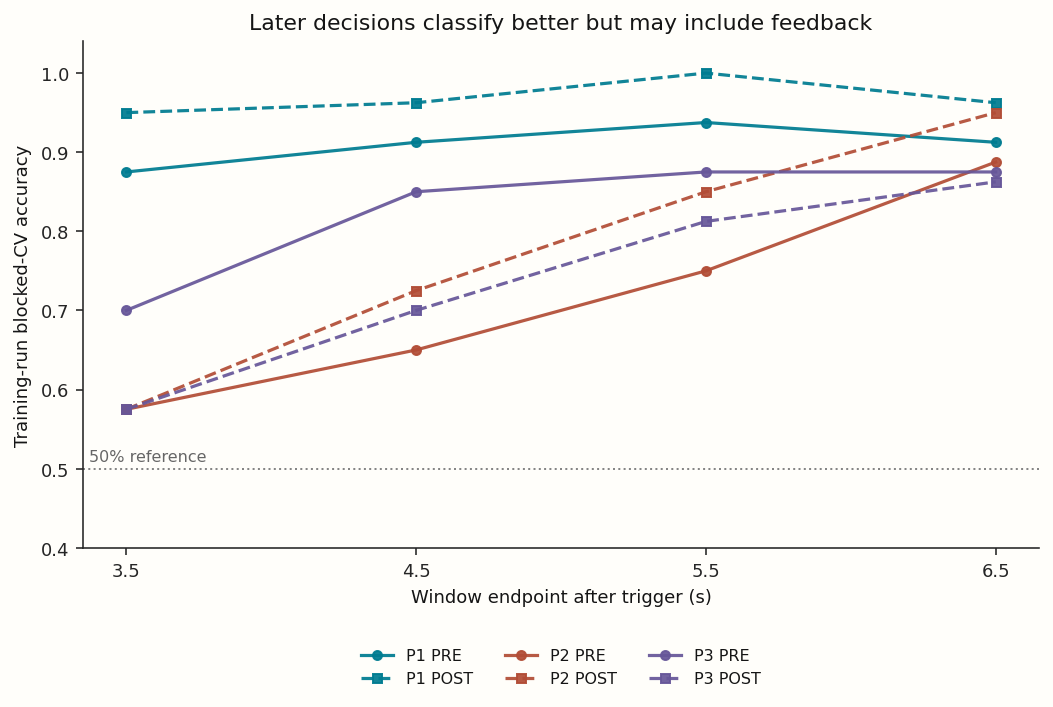

Saved results/causal_latency.png


In [2]:
with plt.rc_context({
    "font.family": "DejaVu Sans", "font.size": 9, "axes.titlesize": 11,
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "savefig.dpi": 320,
}):
    fig, ax = plt.subplots(figsize=(7.2, 4.8), layout="constrained")
    colors = {"P1": "#007C91", "P2": "#B24D36", "P3": "#675799"}
    for patient in ("P1", "P2", "P3"):
        for session in ("pre", "post"):
            selected = sorted((r for r in rows if r["patient"] == patient
                               and r["session"] == session),
                              key=lambda r: float(r["stop_s"]))
            ax.plot([float(r["stop_s"]) for r in selected],
                    [float(r["accuracy"]) for r in selected],
                    label=f"{patient} {session.upper()}", color=colors[patient],
                    linestyle="-" if session == "pre" else "--",
                    marker="o" if session == "pre" else "s", lw=1.6,
                    markersize=4.5, alpha=0.93)
    ax.axhline(0.5, color="#858585", ls=":", lw=1, zorder=0)
    ax.set(xlim=(3.35, 6.65), ylim=(0.4, 1.04), xticks=[3.5, 4.5, 5.5, 6.5],
           xlabel="Window endpoint after trigger (s)",
           ylabel="Training-run blocked-CV accuracy",
           title="Later decisions classify better but may include feedback")
    ax.text(3.37, 0.51, "50% reference", color="#666666", fontsize=8)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3,
              frameon=False, columnspacing=2, fontsize=8)
    path = Path("results/causal_latency.png")
    fig.savefig(path, dpi=320, bbox_inches="tight", facecolor="white")
    plt.show()
print("Saved results/causal_latency.png")
